# Bonus Project 1

In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
# import statsmodels.api as sm

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, log_loss

RANDOM_SEED = 21352822
DATA_DIR = Path("../data")

print("DATA_DIR:", DATA_DIR.resolve())

DATA_DIR: /Users/ethan/Code Repository/MSDM 5054/Project/Bonus-Project 1/data


## 1. Load Data

In [9]:
Default_df = pd.read_csv(DATA_DIR / "Default.csv")

print(Default_df.shape)
Default_df.head()


(10000, 5)


,rownames,default,student,balance,income
0,1,No,No,729.526495,44361.625074
1,2,No,Yes,817.180407,12106.134700
2,3,No,No,1073.549164,31767.138947
3,4,No,No,529.250605,35704.493935
4,5,No,No,785.655883,38463.495879


In [10]:
data = Default_df[["default", "student", "balance", "income"]].copy()
data["default"] = (data["default"] == "Yes").astype(int)
data["student"] = (data["student"] == "Yes").astype(int)

FEATURES_3 = ["balance", "income", "student"]
FEATURES_2 = ["balance", "student"]

X_3 = data[FEATURES_3]
X_2 = data[FEATURES_2]
y = data["default"].to_numpy()

print("Dataset shape:", data.shape)
print("Default rate:", y.mean())
display(data[FEATURES_3].describe().round(2))


Dataset shape: (10000, 4)
Default rate: 0.0333


,balance,income,student
count,10000.00,10000.00,10000.00
mean,835.37,33516.98,0.29
std,483.71,13336.64,0.46
min,0.00,771.97,0.00
25%,481.73,21340.46,0.00
50%,823.64,34552.64,0.00
75%,1166.31,43807.73,1.00
max,2654.32,73554.23,1.00


### 特征分布

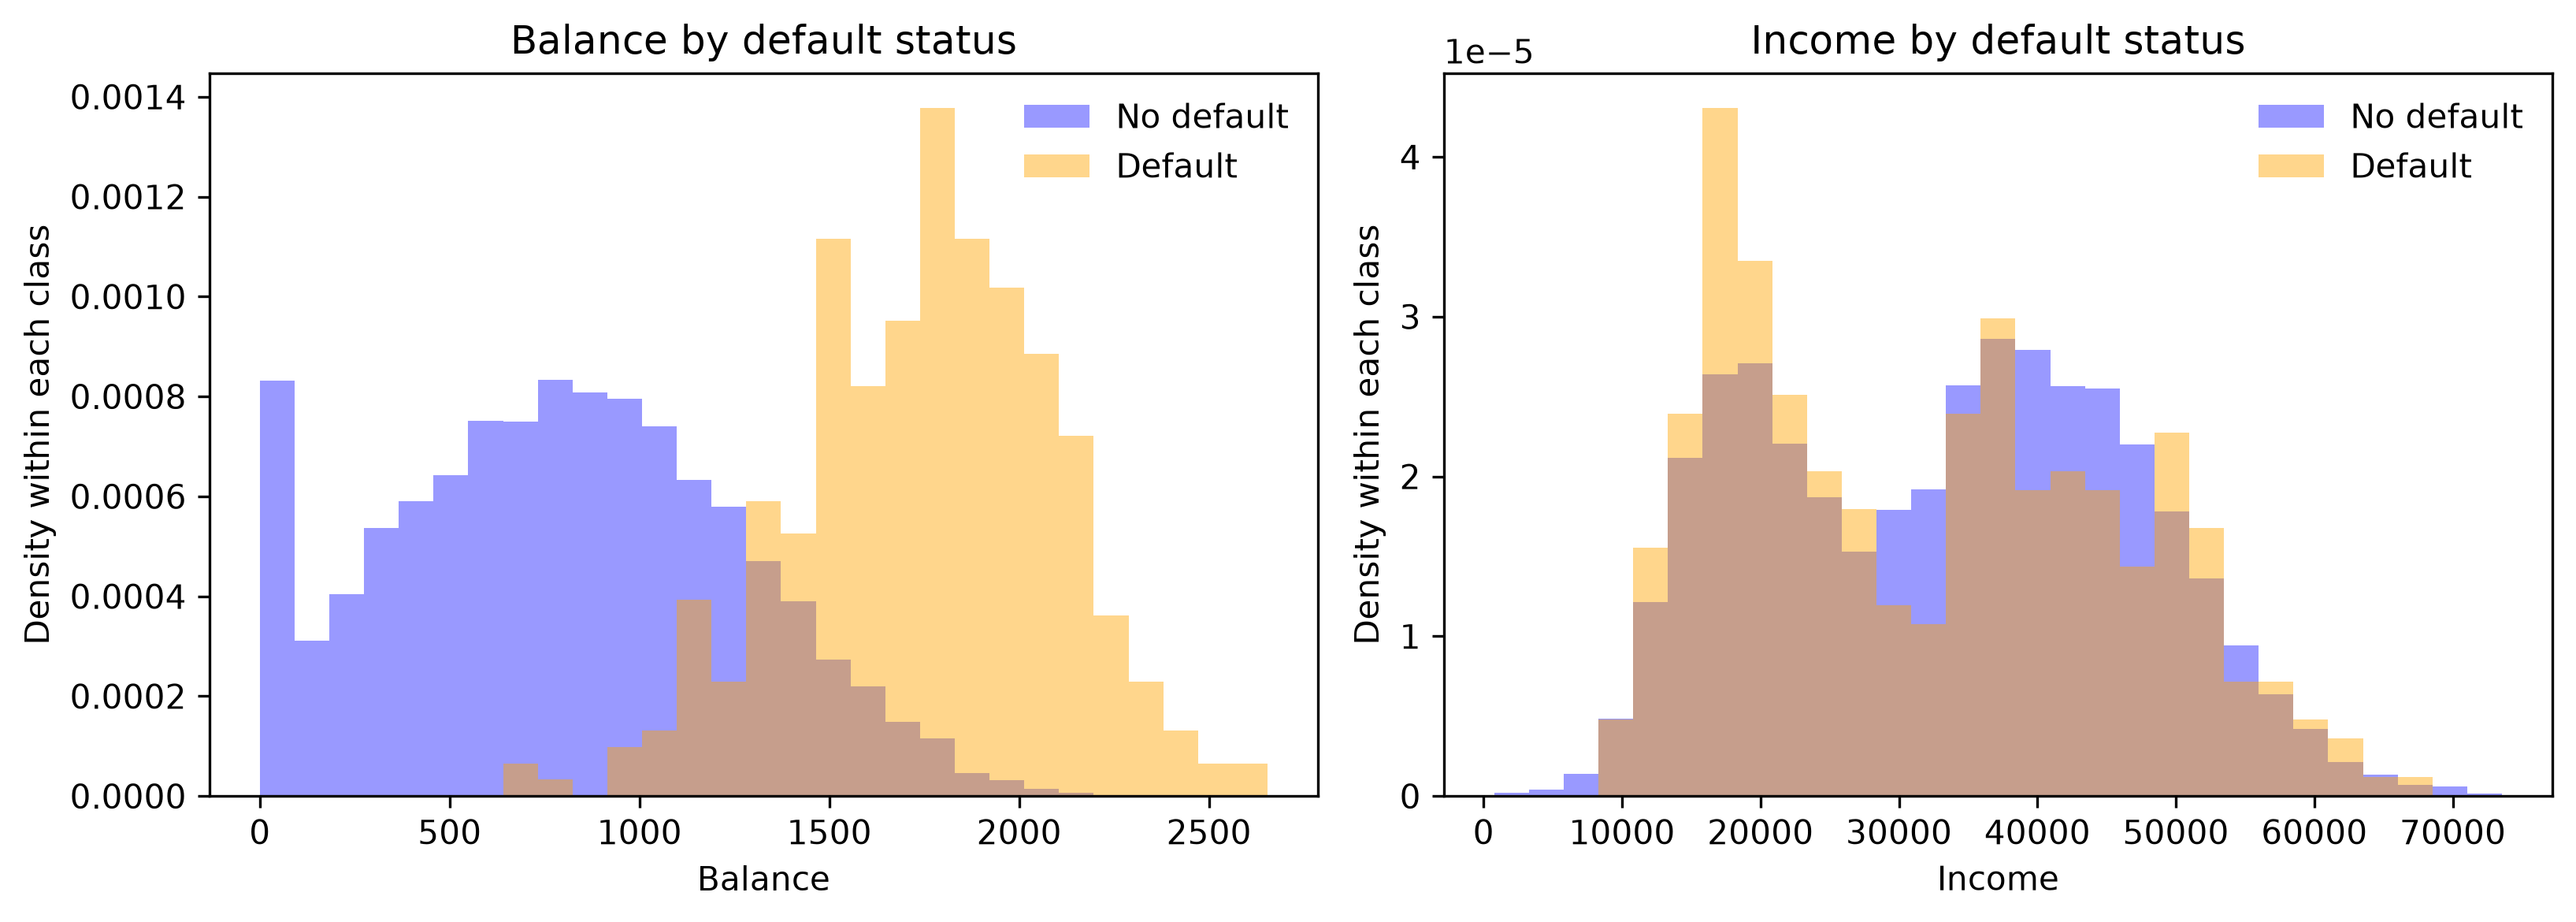

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=300)

for ax, feature in zip(axes, ["balance", "income"]):
    bins = np.linspace(data[feature].min(), data[feature].max(), 30)

    ax.hist(data.loc[y == 0, feature], bins=bins, density=True,
            alpha=0.4, color="blue", label="No default")
    ax.hist(data.loc[y == 1, feature], bins=bins, density=True,
            alpha=0.45, color="orange", label="Default")

    ax.set_xlabel(feature.capitalize())
    ax.set_ylabel("Density within each class")
    ax.set_title(f"{feature.capitalize()} by default status")
    ax.legend(frameon=False)

fig.tight_layout()

# Save
plt.savefig("../result/fig_0", dpi=300, bbox_inches='tight')

plt.show()

## 2. 错误复现

In [12]:
lr_params = {
    "solver": "liblinear",
    "C": 1,
    "tol": 1e-4,
    "max_iter": 100,
    "random_state": RANDOM_SEED
}

lr3_original = LogisticRegression(**lr_params)
lr2_original = LogisticRegression(**lr_params)
lda3 = LinearDiscriminantAnalysis(solver="svd")

lr3_original.fit(X_3, y)
lr2_original.fit(X_2, y)
lda3.fit(X_3, y)

pred_lr3 = lr3_original.predict_proba(X_3)[:, 1]
pred_lr2 = lr2_original.predict_proba(X_2)[:, 1]
pred_lda3 = lda3.predict_proba(X_3)[:, 1]

reproduction = pd.DataFrame({
    "Model": ["LR: 3 features", "LR: 2 features", "LDA: 3 features"],
    "Train AUC": [
        roc_auc_score(y, pred_lr3),
        roc_auc_score(y, pred_lr2),
        roc_auc_score(y, pred_lda3)
    ],
    "Train Log Loss": [
        log_loss(y, pred_lr3),
        log_loss(y, pred_lr2),
        log_loss(y, pred_lda3)
    ]
})

display(reproduction.round(4))
print("LR3 iterations:", lr3_original.n_iter_[0])
print("LR3 iterations:", lr2_original.n_iter_[0])

,Model,Train AUC,Train Log Loss
0,LR: 3 features,0.5951,0.1735
1,LR: 2 features,0.9496,0.0792
2,LDA: 3 features,0.9495,0.0797


LR3 iterations: 9
LR3 iterations: 23


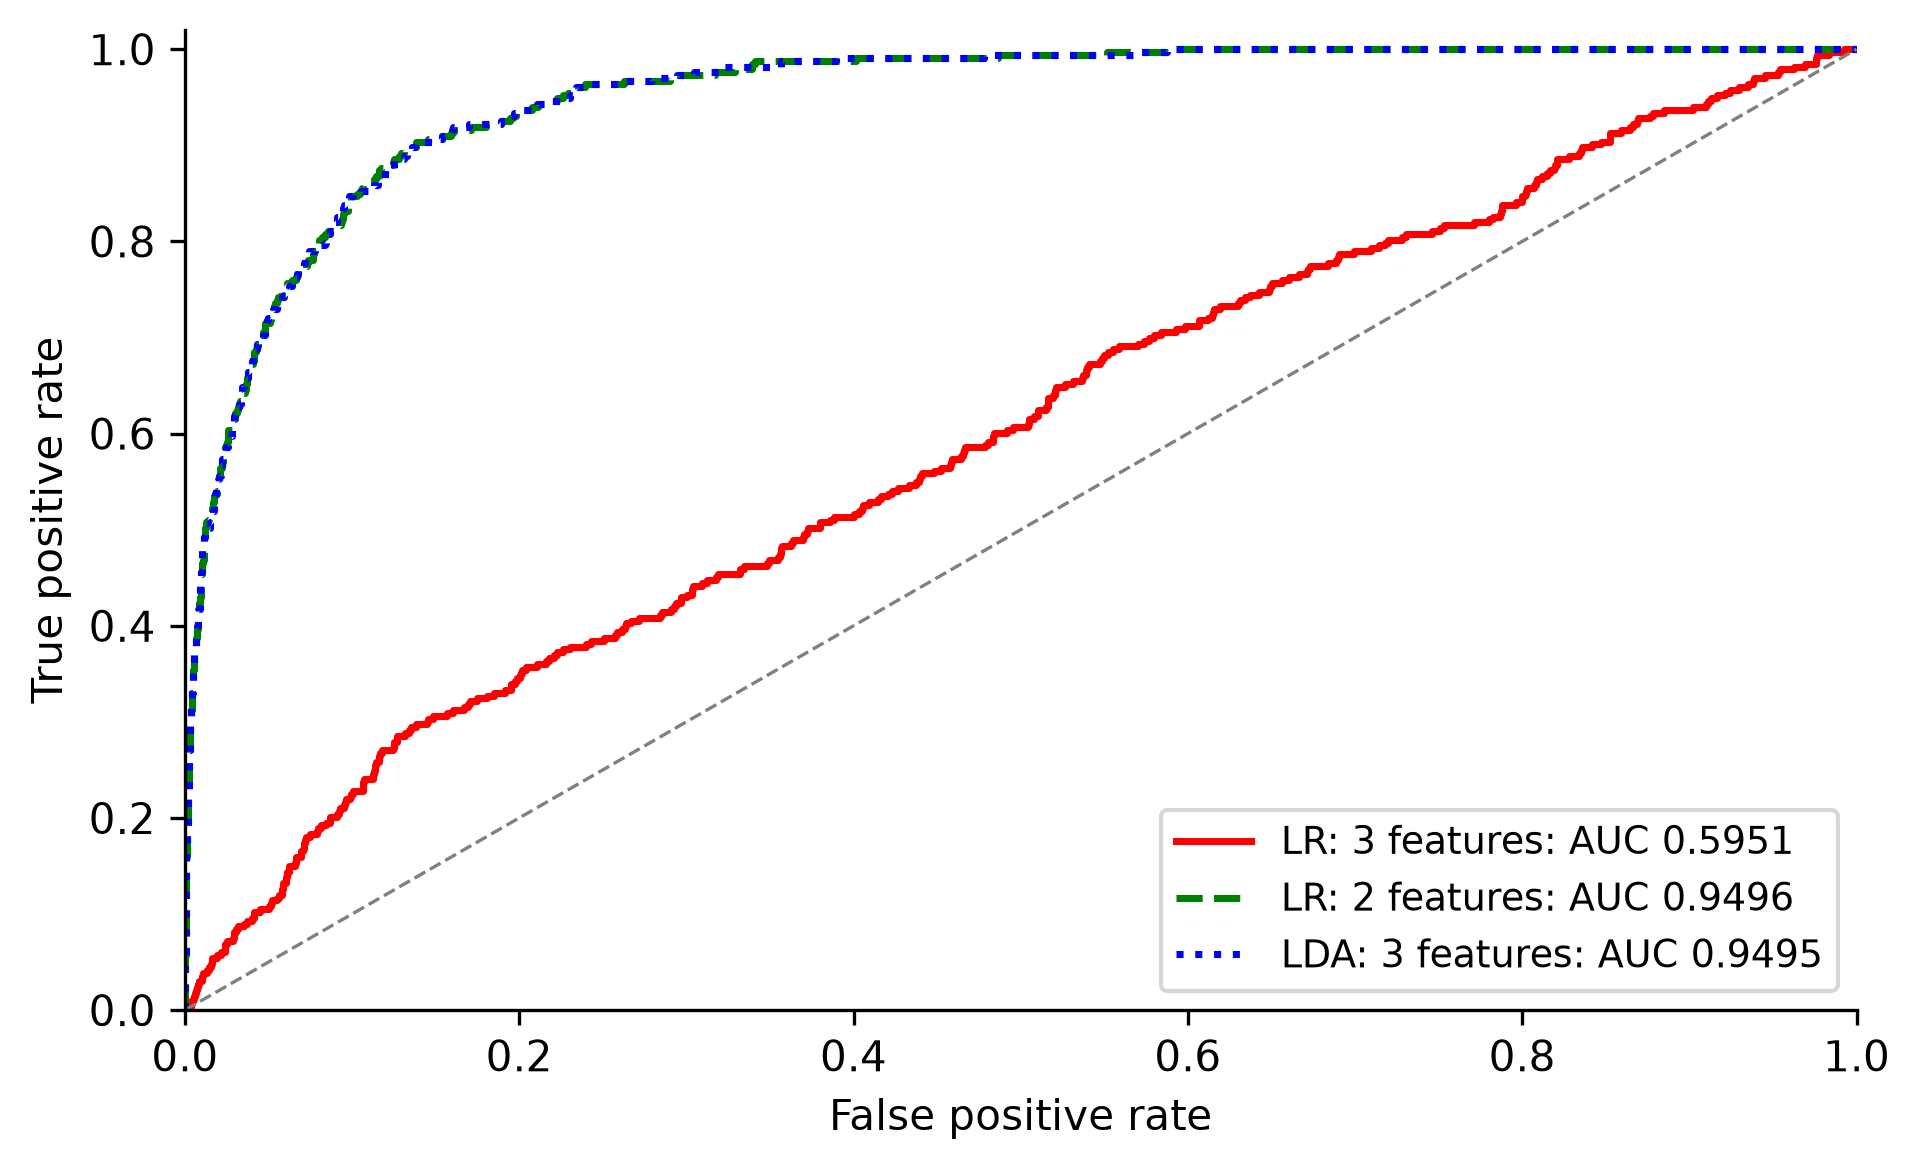

In [37]:
curves = {}

for name, scores in [
    ("LR: 3 features", pred_lr3),
    ("LR: 2 features", pred_lr2),
    ("LDA: 3 features", pred_lda3)
]:
    fpr, tpr, _ = roc_curve(y, scores)
    curves[name] = {
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc_auc_score(y, scores)
    }

styles = {
    "LR: 3 features": ("red", "-"),
    "LR: 2 features": ("green", "--"),
    "LDA: 3 features": ("blue", ":")
}

fig, ax = plt.subplots(figsize=(6.5,4), dpi=300)

for name in ["LR: 3 features", "LR: 2 features", "LDA: 3 features"]:
    color, line_style = styles[name]
    curve = curves[name]
    ax.plot(
        curve["fpr"],
        curve["tpr"],
        color=color,
        ls=line_style,
        lw=1.7,
        label=f"{name}: AUC {curve["auc"]:.4f}"
    )

ax.plot([0, 1], [0, 1], color="gray", ls="--", lw=0.8)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
# ax.set_title("Reproducting the lecture result (training data)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()

# Save
plt.savefig("../result/fig_1", dpi=300, bbox_inches= 'tight')

plt.show()

## 3. Experiment

In [15]:
diagnostic_models = {
    "Original": LogisticRegression(
        solver="liblinear", C=1, tol=1e-4, max_iter=100,
        random_state=RANDOM_SEED
    ),
    "More iterations": LogisticRegression(
        solver="liblinear", C=1, tol=1e-4, max_iter=10000,
        random_state=RANDOM_SEED
    ),
    "Stricter tolerance": LogisticRegression(
        solver="liblinear", C=1, tol=1e-8, max_iter=10000,
        random_state=RANDOM_SEED
    ),
    "StandardScaler": make_pipeline(
        StandardScaler(),
        LogisticRegression(
            solver="liblinear", C=1, tol=1e-4, max_iter=100,
            random_state=RANDOM_SEED
        )
    ),
    "Change to lbfgs": LogisticRegression(
        solver="lbfgs", C=1, tol=1e-4, max_iter=1000,
        random_state=RANDOM_SEED
    )
}

display(diagnostic_models)

{'Original': LogisticRegression(C=1, random_state=21352822, solver='liblinear'),
 'More iterations': LogisticRegression(C=1, max_iter=10000, random_state=21352822,
                    solver='liblinear'),
 'Stricter tolerance': LogisticRegression(C=1, max_iter=10000, random_state=21352822,
                    solver='liblinear', tol=1e-08),
 'StandardScaler': Pipeline(steps=[('standardscaler', StandardScaler()),
                 ('logisticregression',
                  LogisticRegression(C=1, random_state=21352822,
                                     solver='liblinear'))]),
 'Change to lbfgs': LogisticRegression(C=1, max_iter=1000, random_state=21352822)}

In [16]:
diagnostic_rows = []

for name, model in diagnostic_models.items():
    model.fit(X_3, y)
    pred = model.predict_proba(X_3)[:, 1]

    if name == "StandardScaler":
        iterations = model.named_steps["logisticregression"].n_iter_[0]
    else:
        iterations = model.n_iter_[0]

    diagnostic_rows.append({
        "Setting": name,
        "Train AUC": roc_auc_score(y, pred),
        "Train Log Loss": log_loss(y, pred),
        "Iterations": iterations
    })

diagnostic_table = pd.DataFrame(diagnostic_rows)
display(diagnostic_table.round(6))

,Setting,Train AUC,Train Log Loss,Iterations
0,Original,0.595079,0.173455,9
1,More iterations,0.595079,0.173455,9
2,Stricter tolerance,0.948905,0.079346,42
3,StandardScaler,0.949564,0.078667,8
4,Change to lbfgs,0.949571,0.078578,80


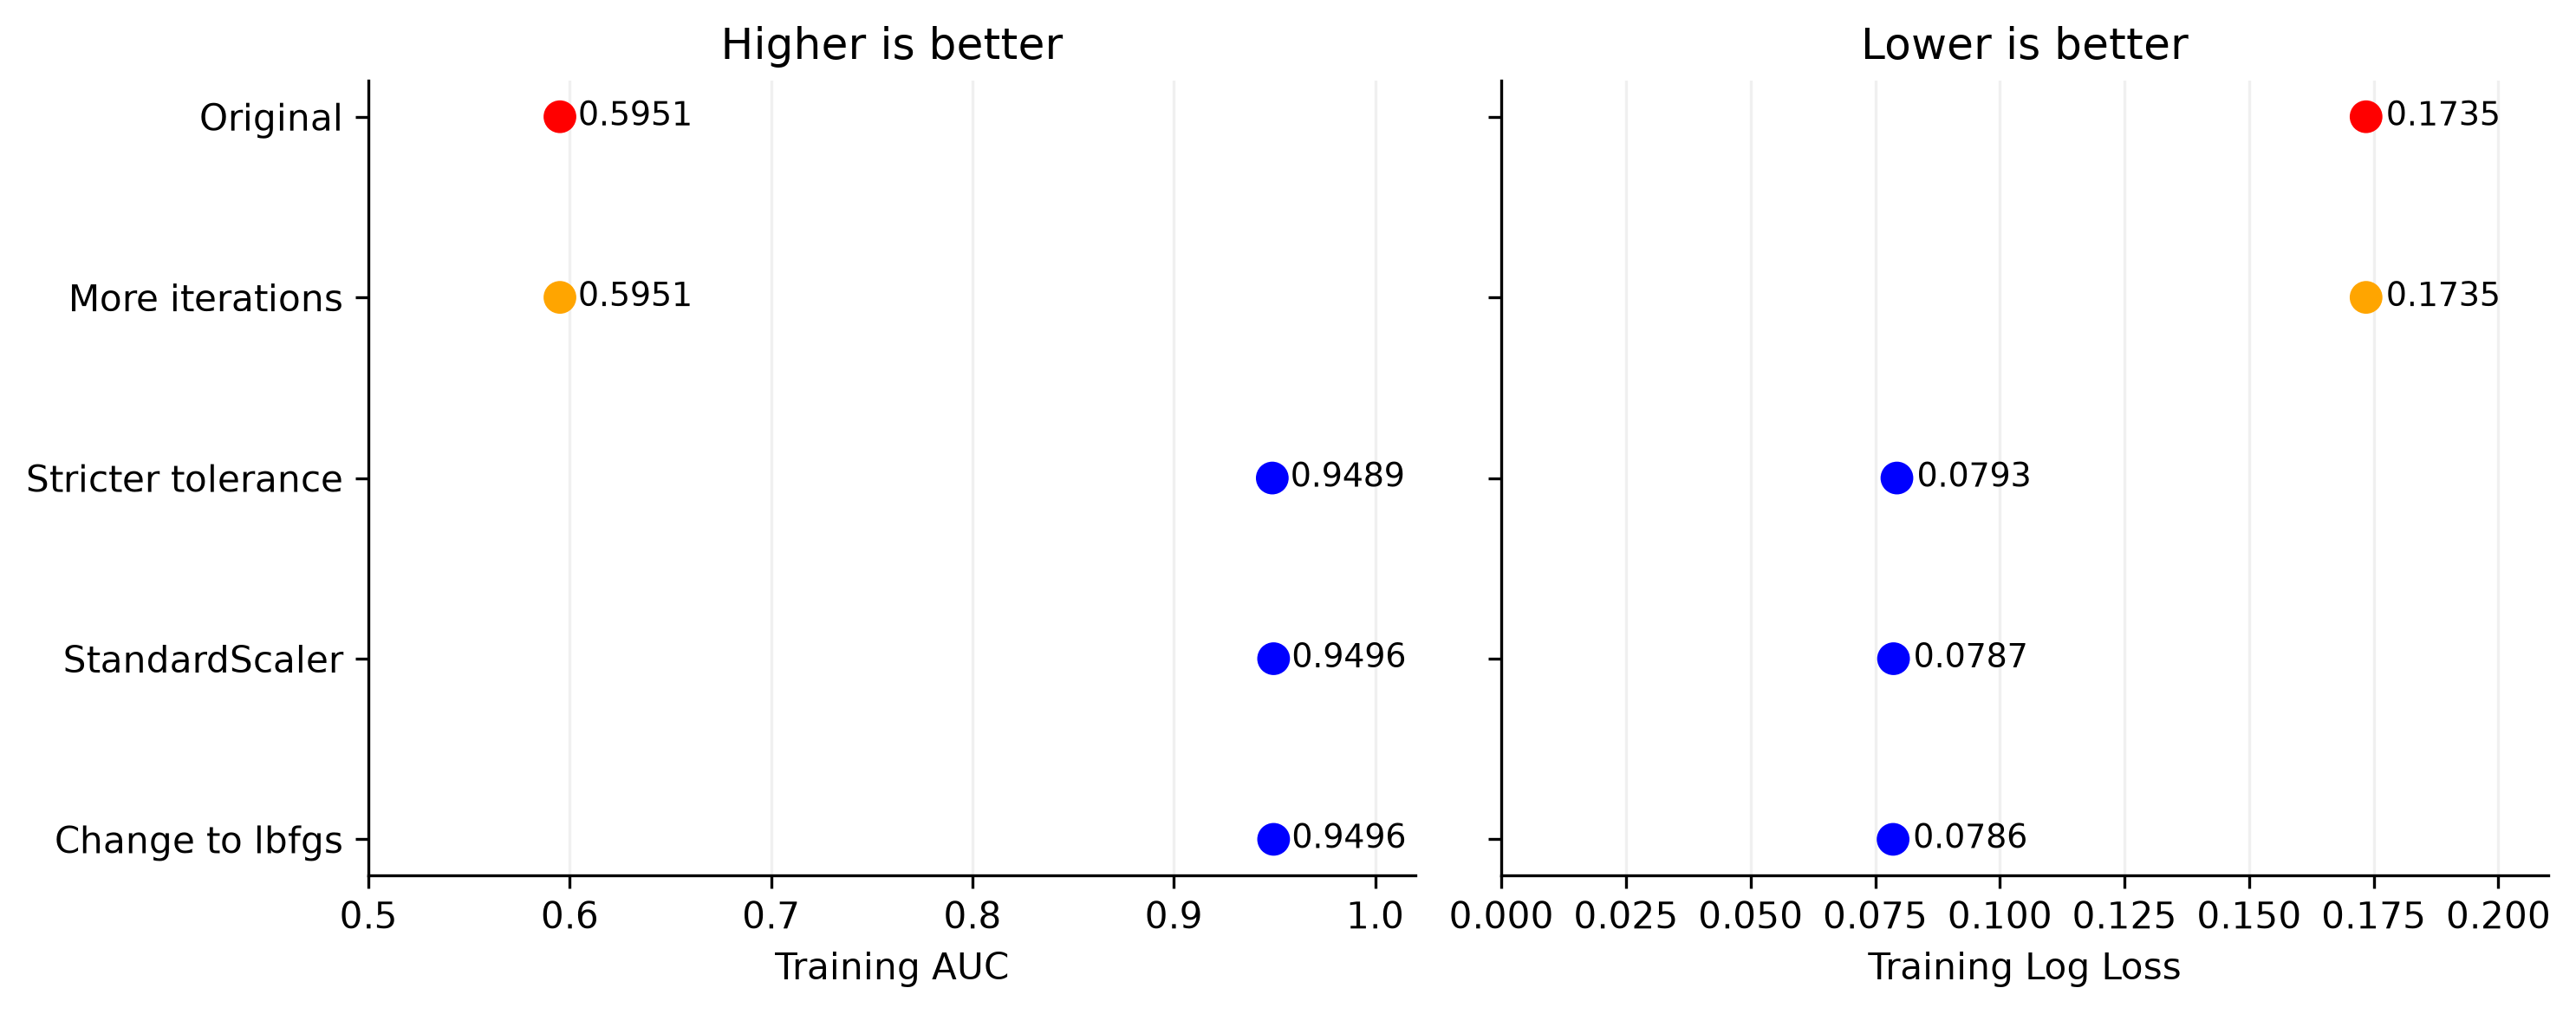

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=300,sharey=True)
plot_table = diagnostic_table.copy()
y_pos = np.arange(len(plot_table))
colors = ["red", "orange", "blue", "blue", "blue"]

for ax, metric, limits, offset in [
    (axes[0], "Train AUC", (0.5, 1.02), 0.009),
    (axes[1], "Train Log Loss", (0, 0.21), 0.004)
]:
    values = plot_table[metric]
    ax.scatter(values, y_pos, c=colors, s=65, zorder=3)
    ax.set_xlim(limits)
    ax.grid(axis="x", alpha=0.18)

    for position, value in enumerate(values):
        ax.text(value + offset, position, f"{value:.4f}", va="center", fontsize=9)

axes[0].set_yticks(y_pos, plot_table["Setting"])
axes[0].invert_yaxis()
axes[0].set(xlabel="Training AUC", title="Higher is better")
axes[1].set(xlabel="Training Log Loss", title="Lower is better")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
fig.tight_layout()

# Save
plt.savefig("../result/fig_2", dpi=300, bbox_inches= 'tight')

plt.show()

In [25]:
train_index, test_index = train_test_split(
    np.arange(len(data)), test_size=0.3, stratify=y, random_state=RANDOM_SEED
)

X3_train = X_3.iloc[train_index]
X2_train = X_2.iloc[train_index]
y_train = y[train_index]

X3_test = X_3.iloc[test_index]
X2_test = X_2.iloc[test_index]
y_test = y[test_index]

print(f"train: {len(y_train)}, {y_train.sum()}")
print(f"test: {len(y_test)}, {y_test.sum()}")

train: 7000, 233
test: 3000, 100


In [26]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=4, random_state=RANDOM_SEED)
cv_rows = []

for fold, (fit_index, valid_index) in enumerate(cv.split(X3_train, y_train), start=1):
    model3 = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            solver="lbfgs", C=1, tol=1e-8, max_iter=1000
        )
    )
    model2 = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            solver="lbfgs", C=1, tol=1e-8, max_iter=1000
        )
    )

    model3.fit(X3_train.iloc[fit_index], y_train[fit_index])
    model2.fit(X2_train.iloc[fit_index], y_train[fit_index])
    pred3 = model3.predict_proba(X3_train.iloc[valid_index])[:, 1]
    pred2 = model2.predict_proba(X2_train.iloc[valid_index])[:, 1]

    auc3 = roc_auc_score(y_train[valid_index], pred3)
    auc2 = roc_auc_score(y_train[valid_index], pred2)
    cv_rows.append({
        "Repeat": (fold - 1) // 5 + 1,
        "Fold": (fold - 1) % 5 + 1,
        "AUC3": auc3,
        "AUC2": auc2,
        "Difference": auc3 - auc2 
    })

cv_results = pd.DataFrame(cv_rows)
display(cv_results.round(6))

,Repeat,Fold,AUC3,AUC2,Difference
0,1,1,0.949345,0.949249,0.000096
1,1,2,0.934911,0.935569,-0.000658
2,1,3,0.953248,0.953468,-0.000220
3,1,4,0.958233,0.958359,-0.000126
4,1,5,0.956063,0.956063,0.000000
5,2,1,0.948060,0.948044,0.000016
6,2,2,0.945797,0.946118,-0.000321
7,2,3,0.940904,0.940872,0.000031
8,2,4,0.942806,0.943561,-0.000755
9,2,5,0.972496,0.972763,-0.000267


In [27]:
cv_summary = pd.DataFrame({
    "Model": ["Scaled LR: 3 features", "Scaled LR: 2 features"],
    "Mean validation AUC": [cv_results["AUC3"].mean(), cv_results["AUC2"].mean()],
    "SD across folds": [cv_results["AUC3"].std(), cv_results["AUC2"].std()]
})
display(cv_summary.round(6))

print(f"平均配对差值（3变量 - 2变量）：{cv_results['Difference'].mean():+.6f}")
print(f"差值范围：{cv_results['Difference'].min():+.6f} 到 {cv_results['Difference'].max():+.6f}")
print("三变量 AUC 更高的折数：", (cv_results["Difference"] > 0).sum(), "/ 20")

,Model,Mean validation AUC,SD across folds
0,Scaled LR: 3 features,0.950319,0.009599
1,Scaled LR: 2 features,0.950570,0.009555


平均配对差值（3变量 - 2变量）：-0.000251
差值范围：-0.000881 到 +0.000096
三变量 AUC 更高的折数： 4 / 20


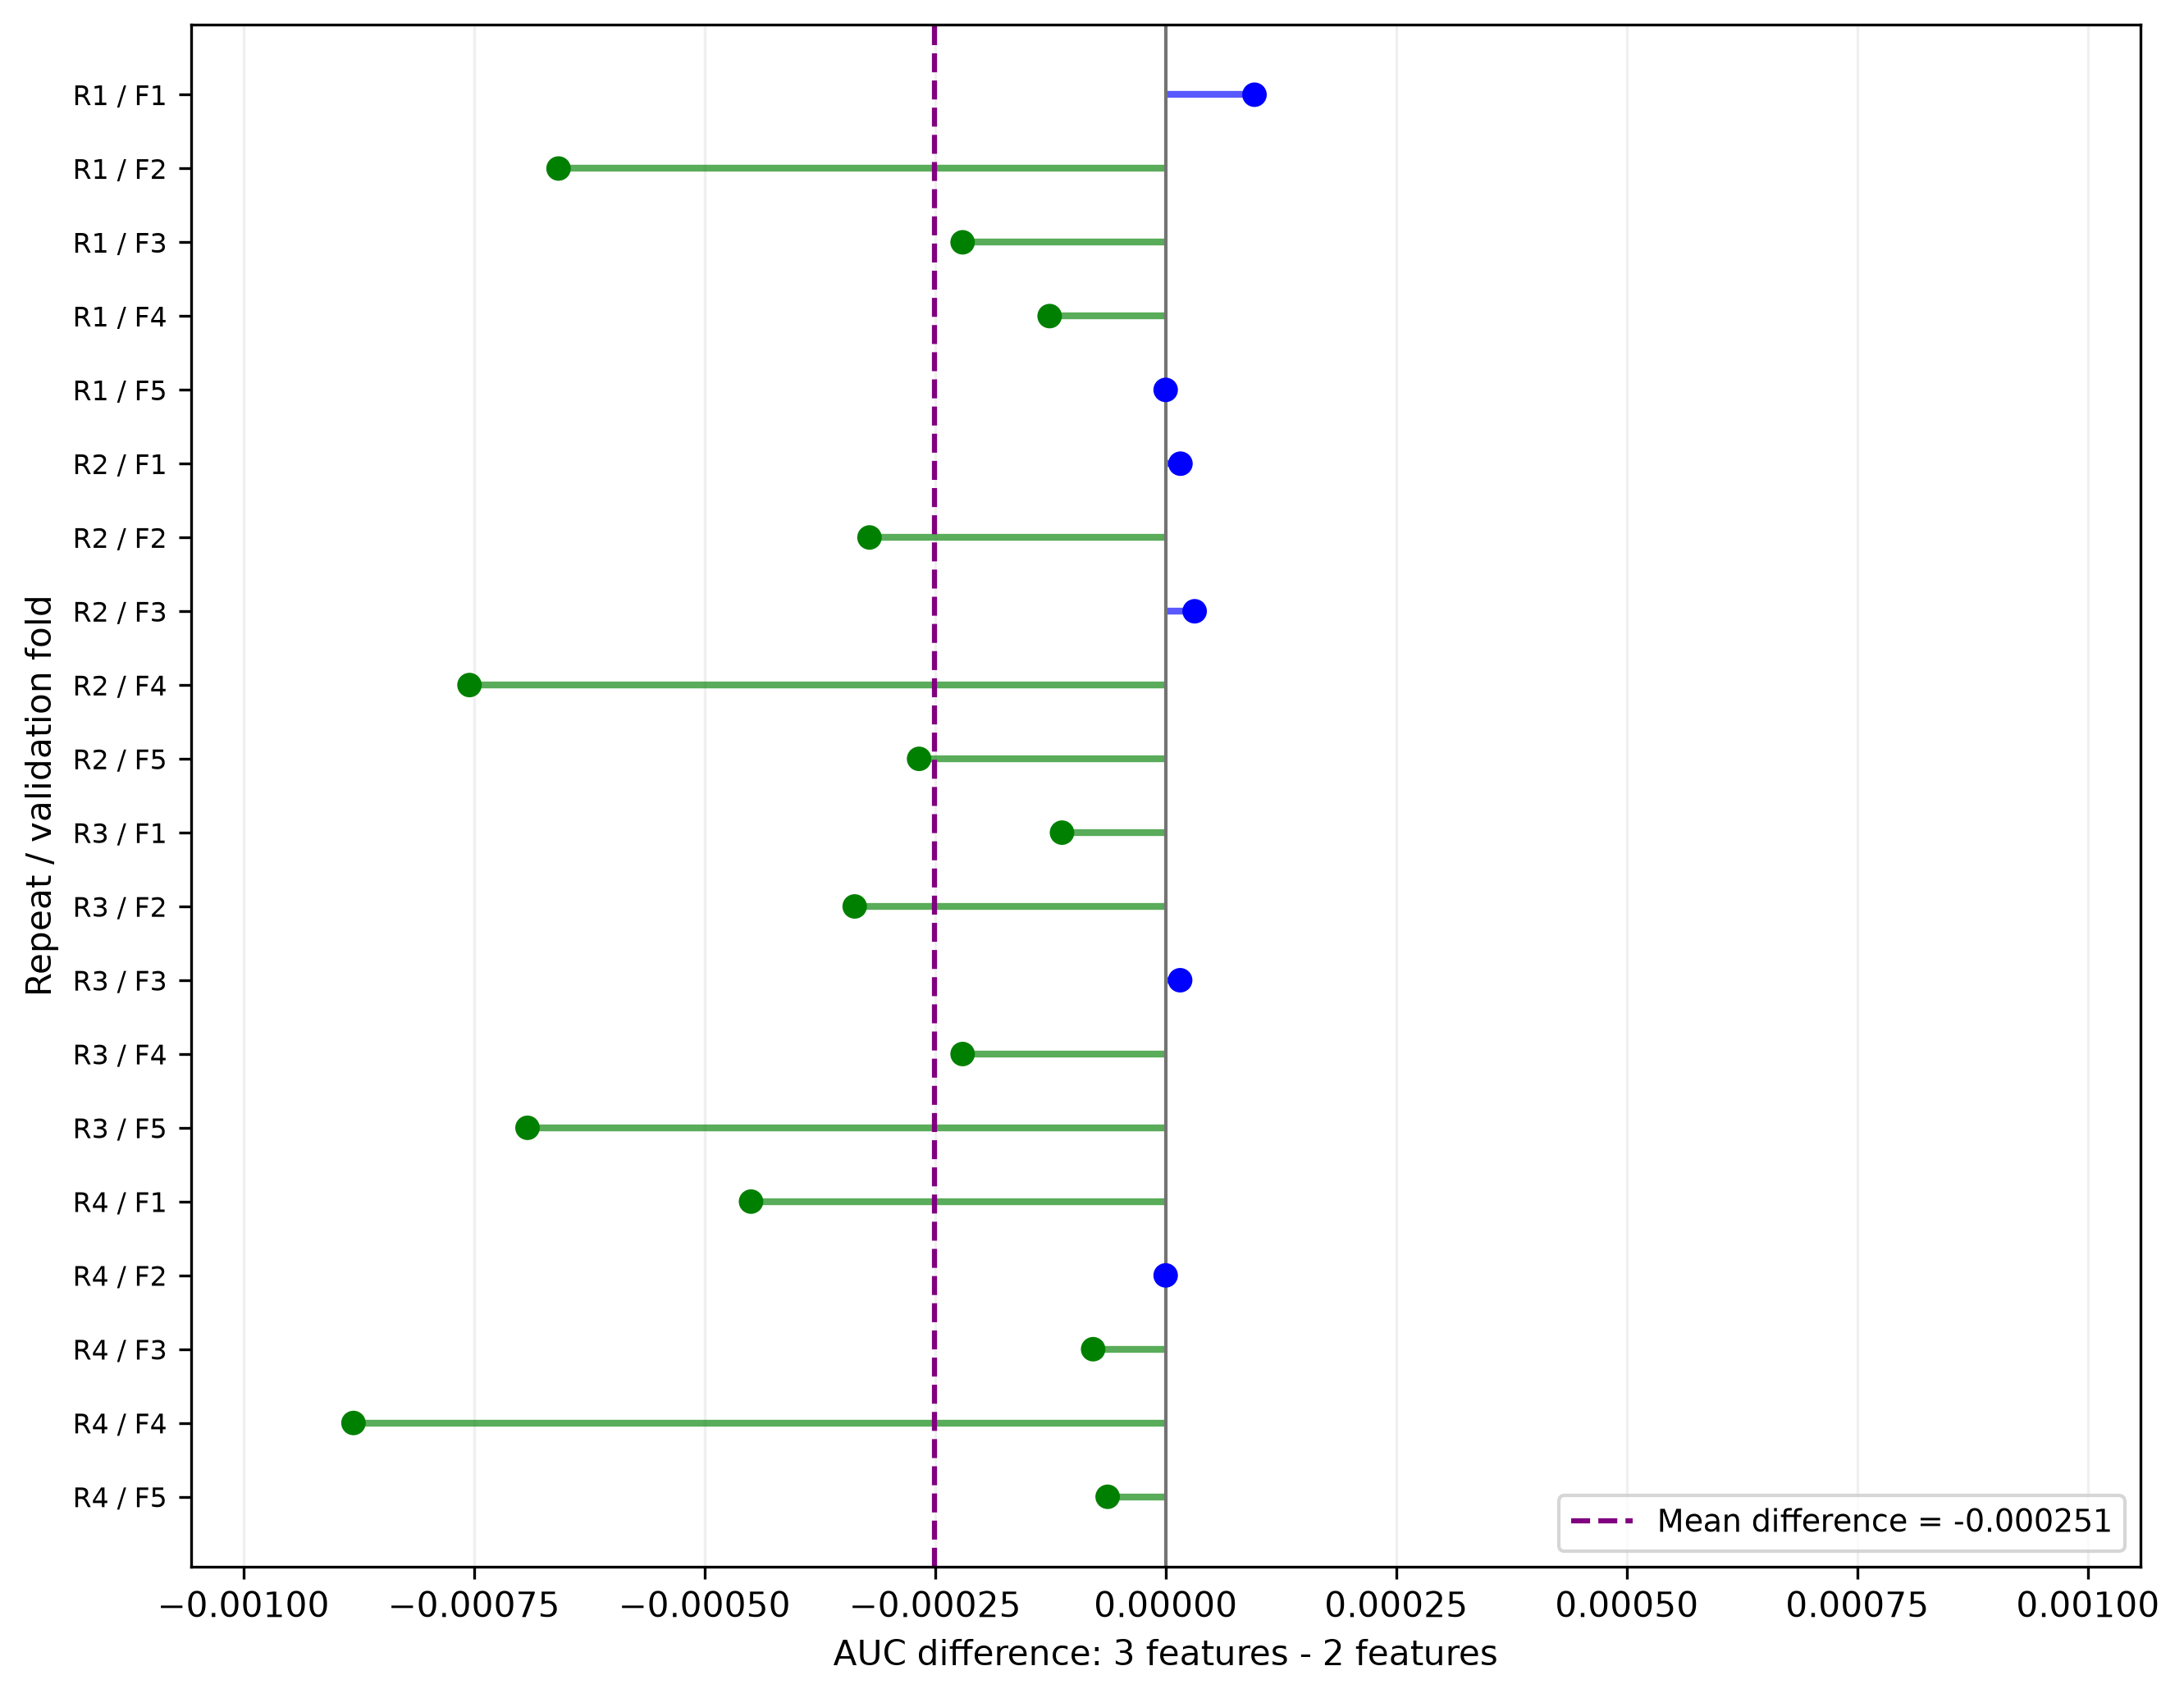

In [39]:
fig, ax = plt.subplots(figsize=(9, 7), dpi=300)
pos = np.arange(len(cv_results))
diff = cv_results["Difference"].to_numpy()
labels = [f"R{r} / F{f}" for r, f in zip(cv_results["Repeat"], cv_results["Fold"])]
colors = np.where(diff >= 0, "blue", "green")

ax.hlines(pos, 0, diff, colors=colors, linewidth=2, alpha=0.65)
ax.scatter(diff, pos, c=colors, s=38, zorder=3)
ax.axvline(0, color="0.45", linewidth=1)
ax.axvline(diff.mean(), color="purple", linestyle="--", linewidth=1.5,
           label=f"Mean difference = {diff.mean():+.6f}")

limit = max(np.abs(diff)) * 1.2
ax.set_xlim(-limit, limit)
ax.set_yticks(pos, labels, fontsize=8)
ax.invert_yaxis()
ax.ticklabel_format(axis="x", style="plain", useOffset=False)
ax.set(
    xlabel="AUC difference: 3 features - 2 features",
    ylabel="Repeat / validation fold"
)
ax.grid(axis="x", alpha=0.18)
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()

# Save
plt.savefig("../result/fig_3", dpi=300, bbox_inches='tight')

plt.show()

In [30]:
test_raw3 = LogisticRegression(
    solver="liblinear", C=1, tol=1e-4, max_iter=100,
    random_state=RANDOM_SEED
)
test_scaled3 = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        solver="lbfgs", C=1, tol=1e-8, max_iter=1000
    )
)
test_scaled2 = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        solver="lbfgs", C=1, tol=1e-8, max_iter=1000
    )
)

test_raw3.fit(X3_train, y_train)
test_scaled3.fit(X3_train, y_train)
test_scaled2.fit(X2_train, y_train)

prob_raw3_test = test_raw3.predict_proba(X3_test)[:, 1]
prob_scaled3_test = test_scaled3.predict_proba(X3_test)[:, 1]
prob_scaled2_test = test_scaled2.predict_proba(X2_test)[:, 1]


In [31]:
test_results = pd.DataFrame({
    "Model": ["Original LR3", "Scaled LR3", "Scaled LR2"],
    "Test AUC": [
        roc_auc_score(y_test, prob_raw3_test),
        roc_auc_score(y_test, prob_scaled3_test),
        roc_auc_score(y_test, prob_scaled2_test)
    ],
    "Test Log Loss": [
        log_loss(y_test, prob_raw3_test),
        log_loss(y_test, prob_scaled3_test),
        log_loss(y_test, prob_scaled2_test)
    ]
})

display(test_results.round(6))

,Model,Test AUC,Test Log Loss
0,Original LR3,0.598807,0.173298
1,Scaled LR3,0.946883,0.077900
2,Scaled LR2,0.946945,0.077824


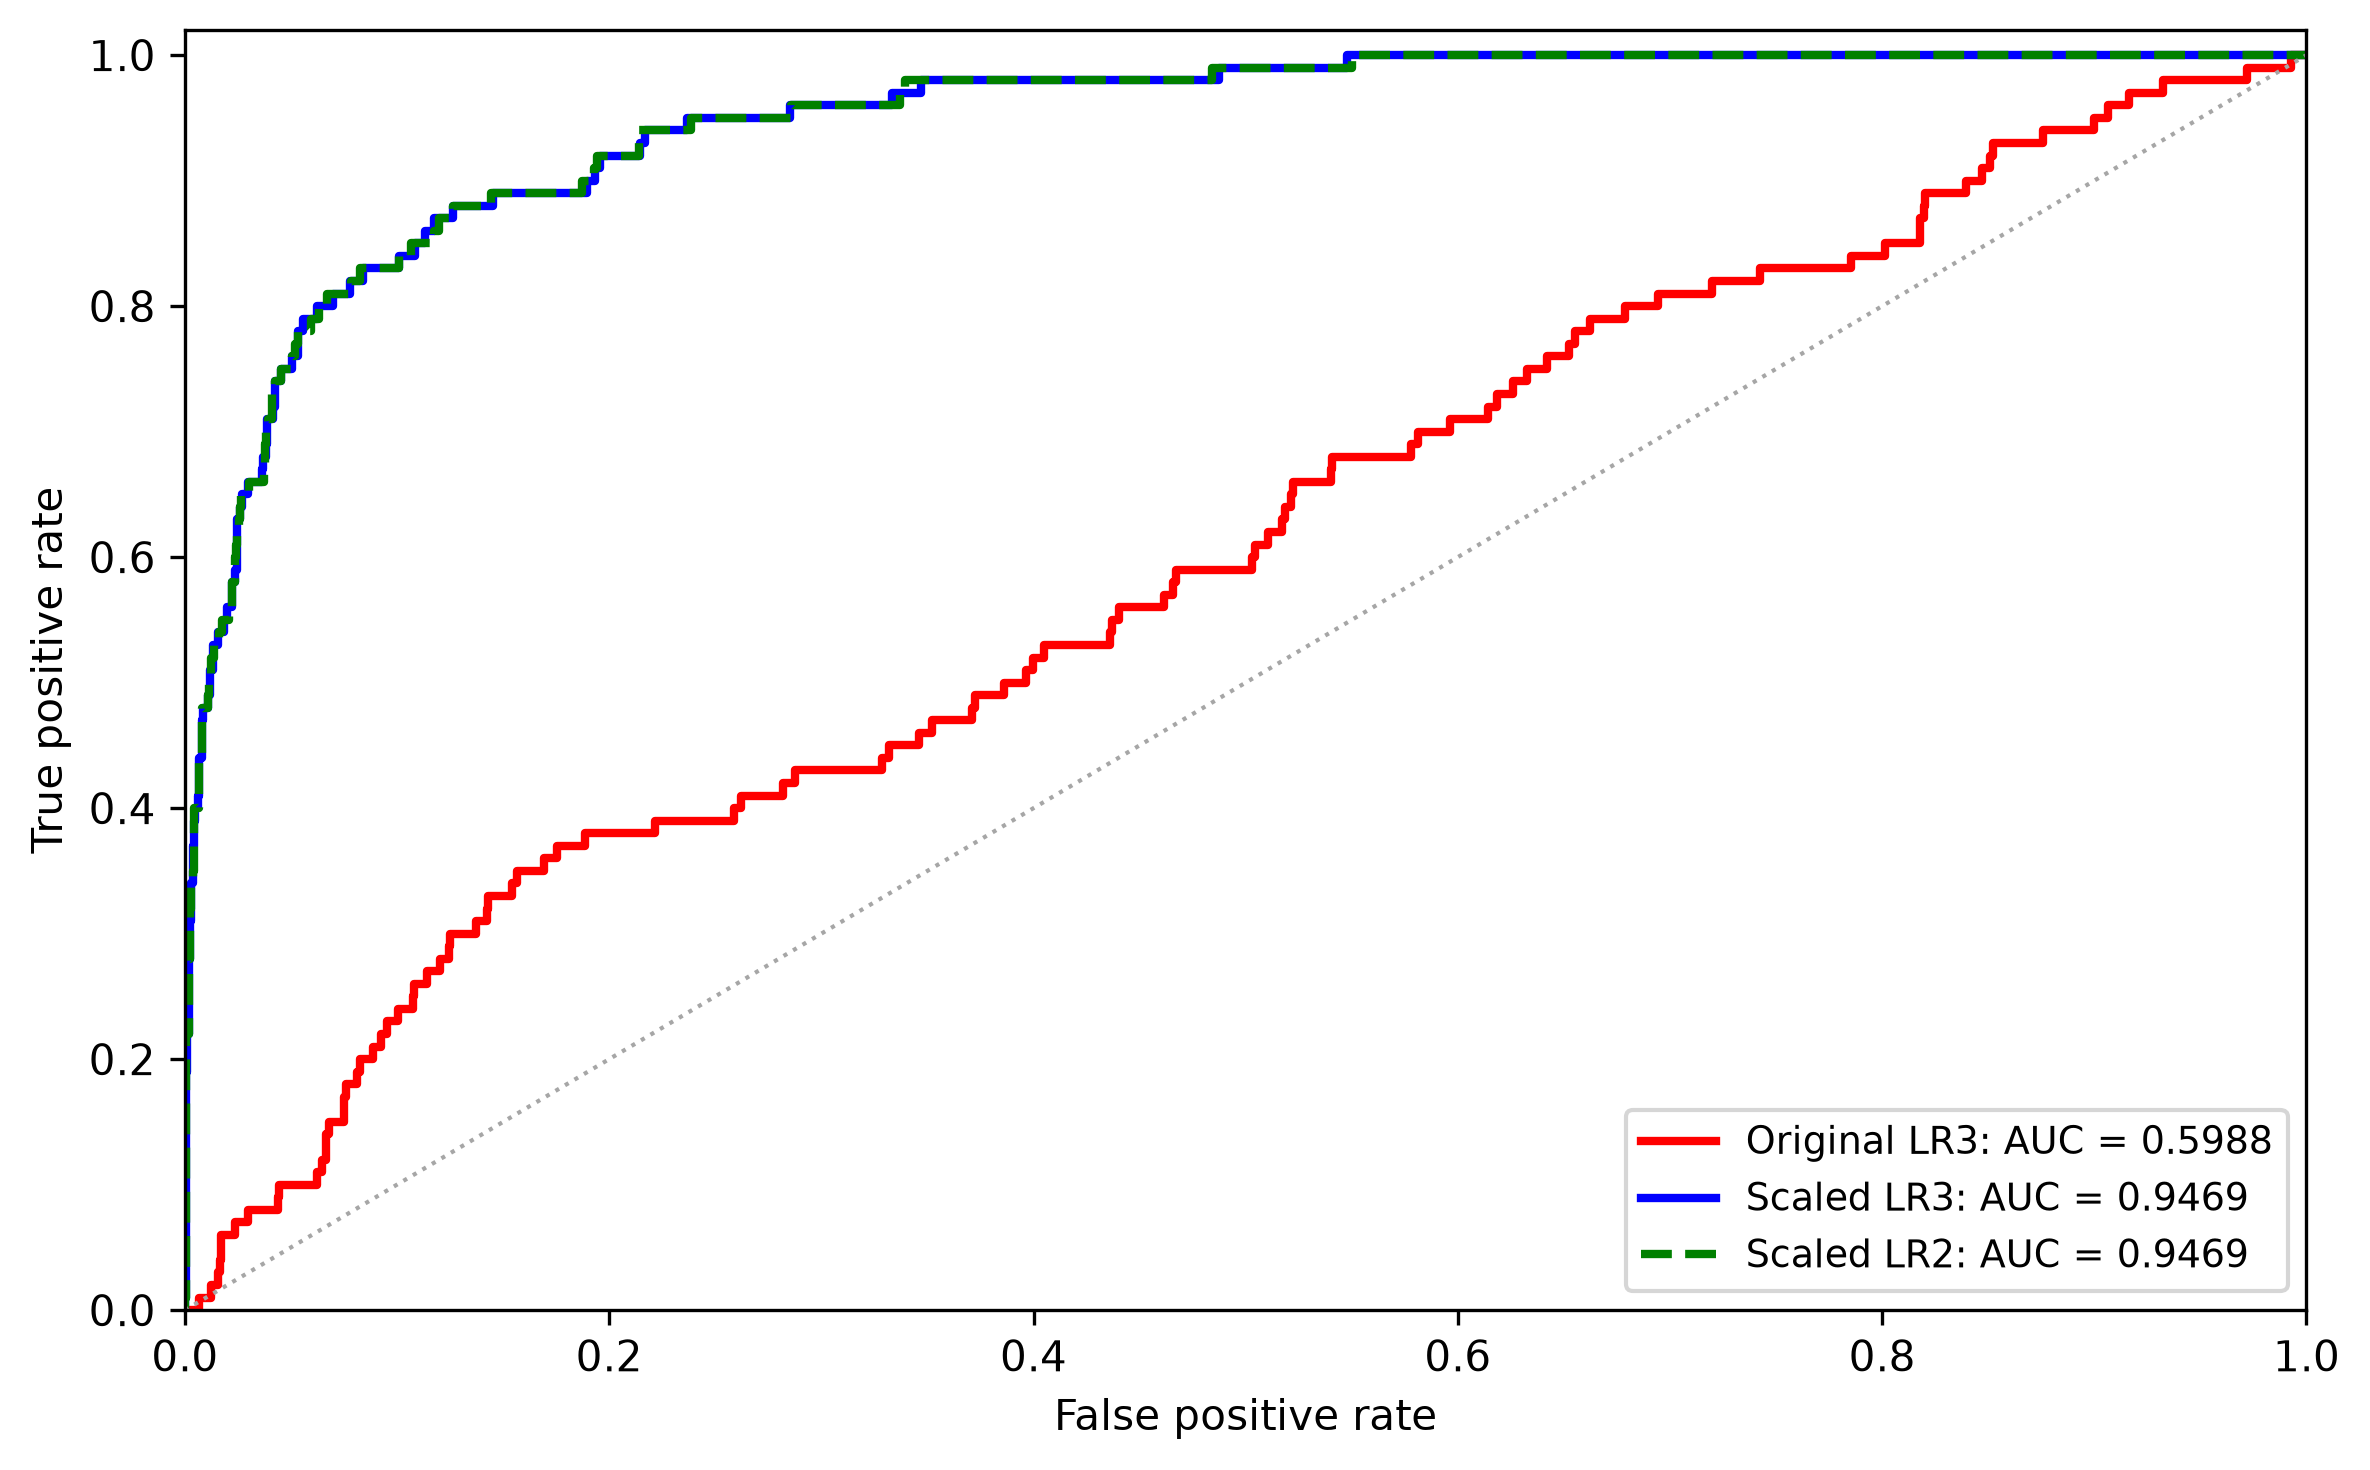

In [40]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

for name, prob, color, style in [
    ("Original LR3", prob_raw3_test, "red", "-"),
    ("Scaled LR3", prob_scaled3_test, "blue", "-"),
    ("Scaled LR2", prob_scaled2_test, "green", "--")
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_value = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, linestyle=style, linewidth=2,
            label=f"{name}: AUC = {auc_value:.4f}")

ax.plot([0, 1], [0, 1], color="0.65", linestyle=":", linewidth=1)
ax.set(
    xlabel="False positive rate",
    ylabel="True positive rate",
    xlim=(0, 1),
    ylim=(0, 1.02)
)
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()

# Save
plt.savefig("../result/fig_4", dpi=300, bbox_inches='tight')

plt.show()